# Comparaci?n de AUC ts-MULE entre m?todos de ranking

Este notebook compara tres formas de ordenar/usar segmentos en las pruebas de fidelidad `deletion` e `insertion`:

1. **Relevancia absoluta**: orden por `|relevancia|`.
2. **Relevancia a secas**: relevancia firmada/orientada para la clase predicha; usa las columnas `positive_first` del CSV 26 si no existe un CSV firmado separado.
3. **Solo secciones positivas**: manipula ?nicamente segmentos con relevancia positiva para la clase predicha.

No recalcula ts-MULE: solo lee los CSV ya generados para todas las instancias.

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()

CSV_FULL = PROJECT_ROOT / 'RESULTADOS_DELETION_INSERTION' / 'tsmule_auc_deletion_insertion_xtest.csv'
CSV_POSITIVE_ONLY = PROJECT_ROOT / 'RESULTADOS_DELETION_INSERTION' / 'tsmule_auc_positive_segments_xtest.csv'
OUTPUT_COMPARISON = PROJECT_ROOT / 'RESULTADOS_DELETION_INSERTION' / 'tsmule_auc_comparativo_metodos.csv'

for path in [CSV_FULL, CSV_POSITIVE_ONLY]:
    if not path.exists():
        raise FileNotFoundError(path)

print('Proyecto:', PROJECT_ROOT)
print('CSV full:', CSV_FULL)
print('CSV positive-only:', CSV_POSITIVE_ONLY)

## 1. Cargar y normalizar CSVs

In [16]:
full = pd.read_csv(CSV_FULL)
pos_only = pd.read_csv(CSV_POSITIVE_ONLY)

full_ok = full[full['error'].fillna('') == ''].copy()
pos_ok = pos_only[pos_only['error'].fillna('') == ''].copy()

base_cols = ['sample_idx', 'predicted_class', 'original_prediction', 'baseline_prediction', 'r2_mean']
base_cols = [c for c in base_cols if c in full_ok.columns]


def rows_from(df, method, deletion_col, insertion_col, gap_col, extra_cols=None):
    extra_cols = extra_cols or []
    cols = [c for c in base_cols + extra_cols if c in df.columns]
    out = df[cols].copy()
    out['method'] = method
    out['deletion_auc'] = df[deletion_col]
    out['insertion_auc'] = df[insertion_col]
    out['gap_auc'] = df[gap_col]
    return out

frames = [
    rows_from(full_ok, 'Relevancia absoluta', 'deletion_auc_abs', 'insertion_auc_abs', 'gap_auc_abs'),
]

# Si alguna vez existe un CSV con columnas firmadas puras, se usa. Si no, se usa positive_first.
if {'deletion_auc_signed', 'insertion_auc_signed', 'gap_auc_signed'}.issubset(full_ok.columns):
    frames.append(rows_from(full_ok, 'Relevancia a secas', 'deletion_auc_signed', 'insertion_auc_signed', 'gap_auc_signed'))
else:
    frames.append(rows_from(full_ok, 'Relevancia a secas', 'deletion_auc_positive_first', 'insertion_auc_positive_first', 'gap_auc_positive_first'))

frames.append(rows_from(
    pos_ok,
    'Solo secciones positivas',
    'deletion_auc_positive',
    'insertion_auc_positive',
    'gap_auc_positive',
    extra_cols=['n_positive_segments'],
))

comparison = pd.concat(frames, ignore_index=True)
comparison = comparison.sort_values(['sample_idx', 'method'])
comparison.to_csv(OUTPUT_COMPARISON, index=False)

print('Muestras full:', len(full_ok))
print('Muestras positive-only:', len(pos_ok))
print('Comparativo:', comparison.shape)
print('Guardado:', OUTPUT_COMPARISON)
comparison.head()

Muestras full: 1017
Muestras positive-only: 1017
Comparativo: (3051, 10)
Guardado: /home/ignacio/Proyectos/Proyecto-XAI-2026-main/RESULTS/tsmule_auc_comparativo_metodos.csv


,sample_idx,predicted_class,original_prediction,baseline_prediction,r2_mean,method,deletion_auc,insertion_auc,gap_auc,n_positive_segments
1017,0,0,0.008333,0.008418,-0.018523,Relevancia a secas,0.008362,0.008456,0.000094,NaN
0,0,0,0.008333,0.008418,-0.018523,Relevancia absoluta,0.008362,0.008456,0.000094,NaN
2034,0,0,0.008333,0.008418,-0.018523,Solo secciones positivas,NaN,NaN,NaN,0.0
1018,1,1,1.000000,0.008418,-1.965259,Relevancia a secas,0.525223,0.957372,0.432148,NaN
1,1,1,1.000000,0.008418,-1.965259,Relevancia absoluta,0.777866,0.985829,0.207963,NaN


## 2. Resumen por metodo

Lectura rapida: `Deletion AUC` menor es mejor, `Insertion AUC` mayor es mejor, y `Gap AUC = Insertion - Deletion` mayor suele ser mas favorable.

In [17]:
summary = comparison.groupby('method').agg(
    n=('sample_idx', 'count'),
    deletion_mean=('deletion_auc', 'mean'),
    deletion_std=('deletion_auc', 'std'),
    deletion_median=('deletion_auc', 'median'),
    insertion_mean=('insertion_auc', 'mean'),
    insertion_std=('insertion_auc', 'std'),
    insertion_median=('insertion_auc', 'median'),
    gap_mean=('gap_auc', 'mean'),
    gap_std=('gap_auc', 'std'),
    gap_median=('gap_auc', 'median'),
).sort_values('gap_mean', ascending=False)

summary

,n,deletion_mean,deletion_std,deletion_median,insertion_mean,insertion_std,insertion_median,gap_mean,gap_std,gap_median
method,,,,,,,,,,
Relevancia a secas,1017,0.262030,0.253331,0.202683,0.418707,0.433120,0.157770,0.156677,0.447405,-0.000569
Solo secciones positivas,1017,0.280492,0.335588,0.088235,0.408016,0.435994,0.065052,0.127524,0.603852,-0.002462
Relevancia absoluta,1017,0.310097,0.326002,0.189219,0.410913,0.392657,0.376800,0.100816,0.224126,0.003618


### Tabla comparativa de medias de AUC

Esta tabla resume las medias de `Deletion AUC` e `Insertion AUC` para cada método. Se guarda también en CSV y LaTeX para usarla en el informe.

In [ ]:
mean_auc_table = (
    comparison.groupby('method', as_index=False)
    .agg(
        n=('sample_idx', 'count'),
        deletion_auc_media=('deletion_auc', 'mean'),
        insertion_auc_media=('insertion_auc', 'mean'),
    )
    .rename(columns={
        'method': 'Metodo',
        'n': 'N muestras',
        'deletion_auc_media': 'Media Deletion AUC',
        'insertion_auc_media': 'Media Insertion AUC',
    })
    .sort_values('M?todo')
)

mean_auc_table[['Media Deletion AUC', 'Media Insertion AUC']] = mean_auc_table[
    ['Media Deletion AUC', 'Media Insertion AUC']
].round(3)

MEAN_AUC_CSV = PROJECT_ROOT / 'RESULTADOS_DELETION_INSERTION' / 'tsmule_auc_medias_por_metodo.csv'
MEAN_AUC_TEX = PROJECT_ROOT / 'RESULTADOS_DELETION_INSERTION' / 'tsmule_auc_medias_por_metodo.tex'
mean_auc_table.to_csv(MEAN_AUC_CSV, index=False)
mean_auc_table.to_latex(MEAN_AUC_TEX, index=False, escape=False)

display(mean_auc_table)
print('CSV:', MEAN_AUC_CSV)
print('LaTeX:', MEAN_AUC_TEX)


,M?todo,N muestras,Media Deletion AUC,Media Insertion AUC
0,Relevancia a secas,1017,0.262,0.419
1,Relevancia absoluta,1017,0.310,0.411
2,Solo secciones positivas,1017,0.280,0.408


CSV: /home/ignacio/Proyectos/Proyecto-XAI-2026-main/RESULTS/tsmule_auc_medias_por_metodo.csv
LaTeX: /home/ignacio/Proyectos/Proyecto-XAI-2026-main/RESULTS/tsmule_auc_medias_por_metodo.tex


In [19]:
if 'predicted_class' in comparison.columns:
    class_summary = comparison.groupby(['predicted_class', 'method']).agg(
        n=('sample_idx', 'count'),
        deletion_mean=('deletion_auc', 'mean'),
        insertion_mean=('insertion_auc', 'mean'),
        gap_mean=('gap_auc', 'mean'),
        gap_median=('gap_auc', 'median'),
    ).sort_index()
    display(class_summary)
else:
    print('No hay columna predicted_class en los CSV.')

n  deletion_mean  insertion_mean  \
predicted_class method                                                         
0               Relevancia a secas        600       0.247936        0.075163   
                Relevancia absoluta       600       0.114998        0.137170   
                Solo secciones positivas  600       0.370805        0.053046   
1               Relevancia a secas        417       0.282308        0.913014   
                Relevancia absoluta       417       0.590815        0.804789   
                Solo secciones positivas  417       0.156610        0.894928   

                                          gap_mean  gap_median  
predicted_class method                                          
0               Relevancia a secas       -0.172773   -0.047185  
                Relevancia absoluta       0.022172    0.000245  
                Solo secciones positivas -0.317758   -0.126919  
1               Relevancia a secas        0.630706    0.645486  
                Relevancia absoluta       0.213974    0.191226  
                Solo secciones positivas  0.738318    0.812010

## 3. Graficos globales

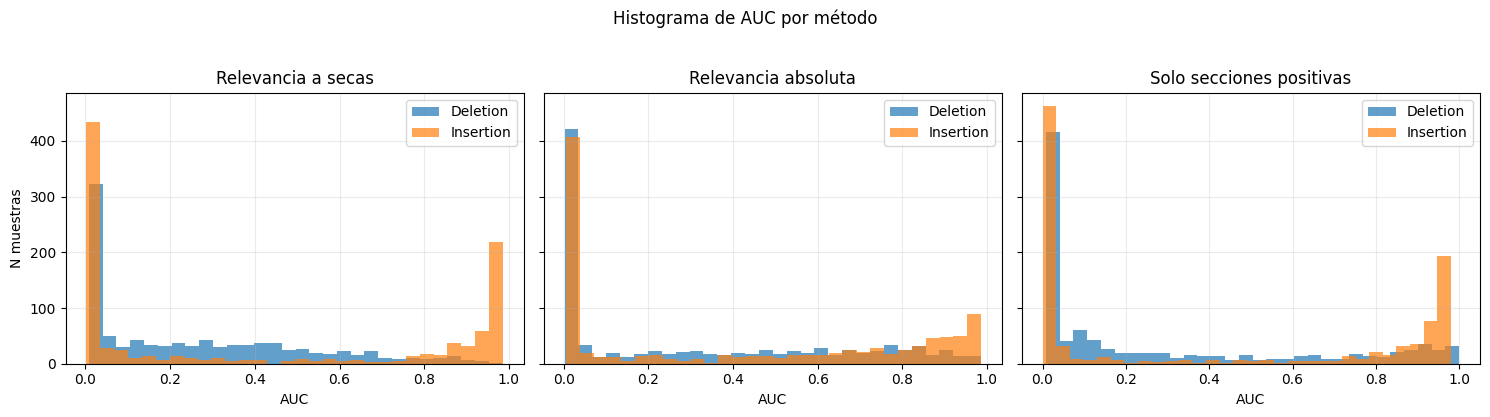

In [20]:
methods = list(comparison['method'].dropna().unique())

fig, axes = plt.subplots(1, len(methods), figsize=(5 * len(methods), 4), sharey=True)
if len(methods) == 1:
    axes = [axes]

for ax, method in zip(axes, methods):
    group = comparison[comparison['method'] == method]
    ax.hist(group['deletion_auc'].dropna(), bins=30, alpha=.7, label='Deletion')
    ax.hist(group['insertion_auc'].dropna(), bins=30, alpha=.7, label='Insertion')
    ax.set_title(method)
    ax.set_xlabel('AUC')
    ax.grid(alpha=.25)
    ax.legend()

axes[0].set_ylabel('N muestras')
fig.suptitle('Histograma de AUC por método', y=1.03)
plt.tight_layout()
plt.show()

/tmp/ipykernel_25616/1865304044.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=order, showmeans=True)
/tmp/ipykernel_25616/1865304044.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=order, showmeans=True)
/tmp/ipykernel_25616/1865304044.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=order, showmeans=True)


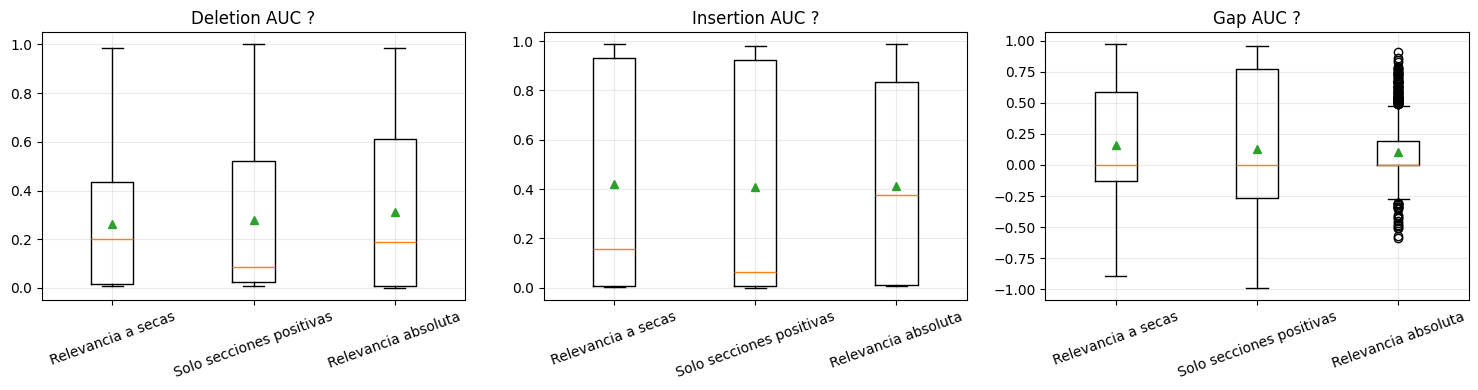

In [21]:
order = summary.index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics = [
    ('deletion_auc', 'Deletion AUC ?'),
    ('insertion_auc', 'Insertion AUC ?'),
    ('gap_auc', 'Gap AUC ?'),
]

for ax, (col, title) in zip(axes, metrics):
    data = [comparison.loc[comparison['method'] == method, col].dropna() for method in order]
    ax.boxplot(data, labels=order, showmeans=True)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=20)
    ax.grid(alpha=.25)

plt.tight_layout()
plt.show()

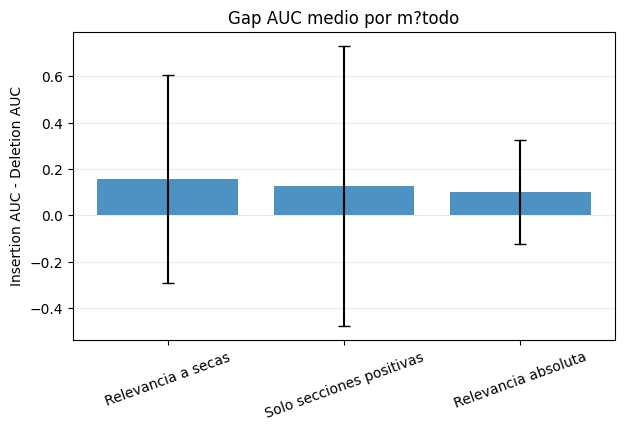

In [22]:
fig, ax = plt.subplots(figsize=(7, 4))
means = summary.loc[order, 'gap_mean']
stds = summary.loc[order, 'gap_std']
ax.bar(order, means, yerr=stds, capsize=4, alpha=.8)
ax.set(title='Gap AUC medio por m?todo', ylabel='Insertion AUC - Deletion AUC')
ax.tick_params(axis='x', rotation=20)
ax.grid(axis='y', alpha=.25)
plt.show()

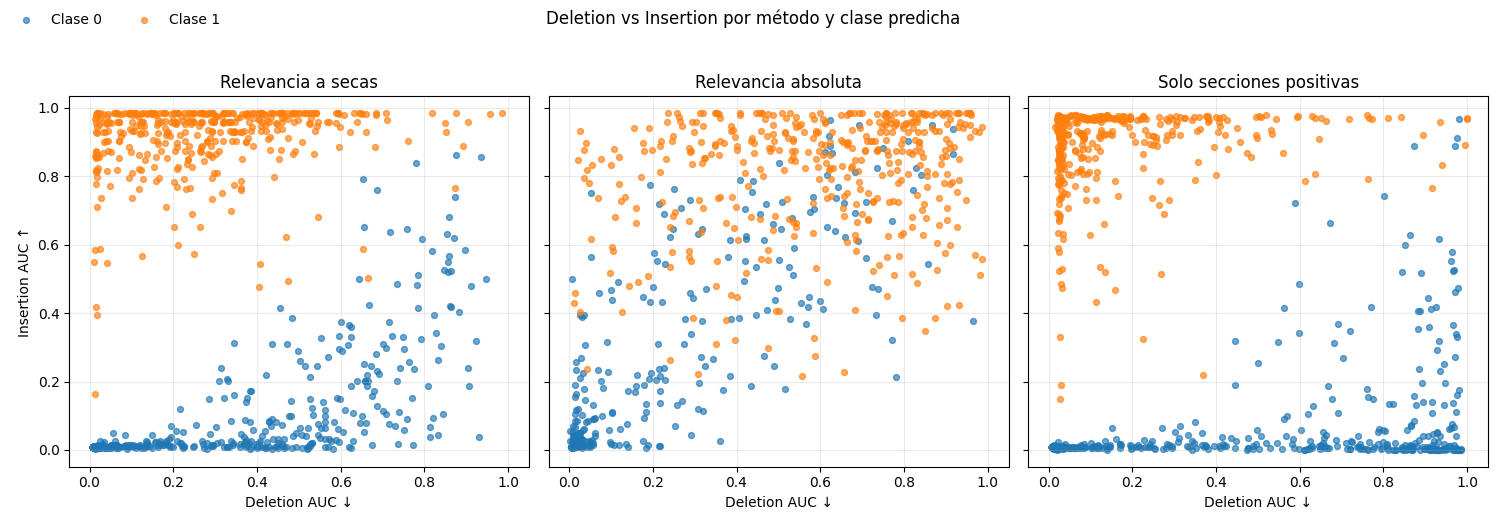

In [27]:
methods = list(comparison['method'].dropna().unique())
class_colors = {0: 'tab:blue', 1: 'tab:orange'}

fig, axes = plt.subplots(1, len(methods), figsize=(5 * len(methods), 5), sharex=True, sharey=True)
if len(methods) == 1:
    axes = [axes]

for ax, method in zip(axes, methods):
    method_data = comparison[comparison['method'] == method]
    for class_id, group in method_data.groupby('predicted_class'):
        ax.scatter(
            group['deletion_auc'], group['insertion_auc'],
            s=18, alpha=.65, color=class_colors.get(class_id),
            label=f'Clase {int(class_id)}',
        )
    ax.set_title(method)
    ax.set_xlabel('Deletion AUC ↓')
    ax.grid(alpha=.25)

axes[0].set_ylabel('Insertion AUC ↑')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper left', ncol=2, frameon=False)
fig.suptitle('Deletion vs Insertion por método y clase predicha', y=1.03)
plt.tight_layout()
plt.show()

## 4. Comparacion pareada por muestra

In [24]:
pivot = comparison.pivot_table(
    index='sample_idx',
    columns='method',
    values='gap_auc',
    aggfunc='first',
)

if 'Relevancia absoluta' in pivot.columns:
    deltas = pivot.subtract(pivot['Relevancia absoluta'], axis=0)
    display(deltas.describe().T.sort_values('mean', ascending=False))
else:
    display(pivot.describe().T)

,count,mean,std,min,25%,50%,75%,max
method,,,,,,,,
Relevancia a secas,1017.0,0.055861,0.394299,-1.104015,-0.141038,-0.000618,0.347206,1.226255
Solo secciones positivas,989.0,0.023857,0.555713,-1.441693,-0.292159,-0.002797,0.455393,1.286578
Relevancia absoluta,1017.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [25]:
best = comparison.dropna(subset=['gap_auc']).sort_values('gap_auc').groupby('sample_idx').tail(1)

best_counts = best['method'].value_counts().rename_axis('method').to_frame('n_mejor_gap')
display(best_counts)

if 'predicted_class' in best.columns:
    display(pd.crosstab(best['predicted_class'], best['method']))

,n_mejor_gap
method,
Relevancia absoluta,567
Solo secciones positivas,311
Relevancia a secas,139


method,Relevancia a secas,Relevancia absoluta,Solo secciones positivas
predicted_class,,,
0,27,558,15
1,112,9,296


## 5. Casos donde los motodos discrepan

In [ ]:
wide = comparison.pivot_table(
    index='sample_idx',
    columns='method',
    values=['deletion_auc', 'insertion_auc', 'gap_auc'],
    aggfunc='first',
)

if {'Relevancia absoluta', 'Solo secciones positivas'}.issubset(pivot.columns):
    diff = (pivot['Solo secciones positivas'] - pivot['Relevancia absoluta']).rename('delta_gap_pos_vs_abs')
    examples = diff.abs().sort_values(ascending=False).head(10).to_frame()
    examples = examples.join(full_ok.set_index('sample_idx')[[c for c in ['predicted_class', 'original_prediction', 'r2_mean'] if c in full_ok.columns]])
    display(examples)
else:
    print('No eston ambas columnas para comparar positivo vs absoluto.')

,delta_gap_pos_vs_abs,predicted_class,original_prediction,r2_mean
sample_idx,,,,
616,1.441693,0,0.309935,-0.424619
435,1.434897,0,0.480610,-0.559743
691,1.420714,0,0.465966,-0.460511
596,1.331262,0,0.012497,-0.303610
1015,1.325759,0,0.126023,-0.441644
821,1.323967,0,0.135855,-0.884866
993,1.302333,0,0.032717,-1.460447
225,1.286578,1,0.974103,-0.444020
132,1.282166,0,0.141348,-0.521596


### Criterio de lectura

- Si **relevancia absoluta** gana, la señal importante mezcla evidencia a favor y en contra.
- Si **relevancia a secas** gana, importa el signo/orientacion de la contribucion.
- Si **solo secciones positivas** gana, la prediccion est? sostenida por un subconjunto positivo claro.

La metrica practica para comparar es `gap_auc`: mayor gap significa que insertar segmentos recupera mas probabilidad que lo que queda al eliminarlos.